**FORMACIÓN DEL BIOFILM (1 BACTERIA)**

*time-lapse*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time


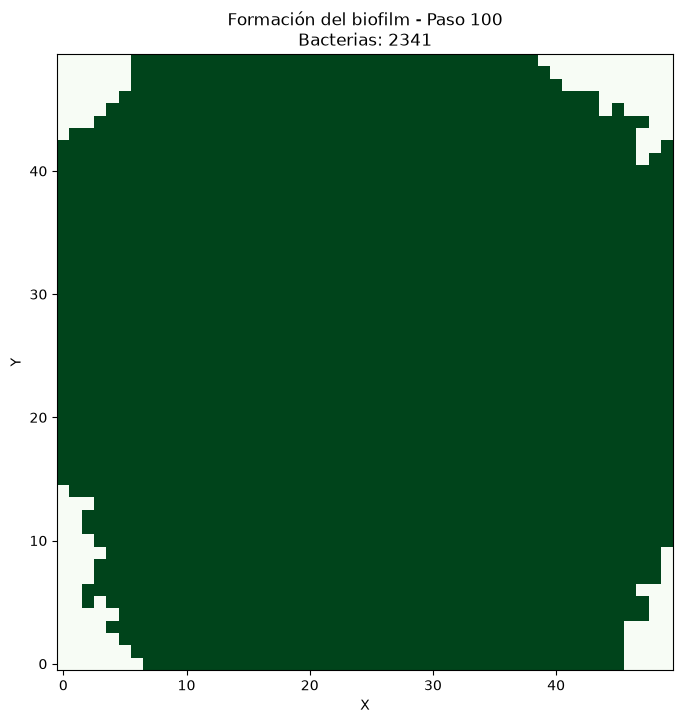

In [4]:

l = 50
b_0 = 5
div_prob = 0.3
steps = 100

lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] == 1:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    lattice[x, y] = 1

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

def divide_bacterium(x, y):
    neighbors = get_neighbors(x, y)
    free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
    if len(free_pos) == 0:            ## si està rodeada no se divide
        return

    daughter_x, daughter_y = random.choice(free_pos)  ## selecciona una posición libre al azar

    lattice[daughter_x, daughter_y] = 1

print("Hola")
for step in range(steps + 1): 
    print("Hola ", step)

    clear_output(wait=True)

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Greens", vmin=0, vmax=1)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacterias: {np.sum(lattice)}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.1)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice == 1))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if lattice[x, y] == 1: 
            if random.random() < div_prob: 
                divide_bacterium(x, y)

**FORMACIÓN DEL BIOFILM (2 BACTERIAS) - NEUTRALISMO**

*time-lapse*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time

l = 500
b_0 = 5
div_prob = 0.3
steps = 100

lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] != 0:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    if random.random() < 0.5:
        lattice[x, y] = 1
    else:
        lattice[x, y] = 2

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors
    

def divide_bacterium(x, y):
    bacteria_type = lattice[x, y]
    neighbors = get_neighbors(x, y)
    free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
    if len(free_pos) == 0:
        return

    daughter_x, daughter_y = random.choice(free_pos)

    lattice[daughter_x, daughter_y] = bacteria_type


for step in range(steps + 1): 
    clear_output(wait=True)

    bacteria_1 = np.sum(lattice == 1)
    bacteria_2 = np.sum(lattice == 2)
    total_bacteria = bacteria_1 + bacteria_2

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Blues", vmin=0, vmax=2)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacteria 1: {bacteria_1}    "
        f"Bacteria 2: {bacteria_2}    "
        f"Total: {total_bacteria}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.1)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice != 0))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if lattice[x, y] != 0:
            if random.random() < div_prob:
                divide_bacterium(x, y)